# **Dataset**

- Dataset: [Link](https://www.kaggle.com/datasets/turkibintalib/saudi-arabia-used-cars-dataset/data)



---



# **Problem DEFINITION**

##What are the datasets about?

- dataset is about used cars from a local Saudi app called "syarah", but the limitation of the dataset is that it doesn't contain a column about if the car has accidents or not and i want to make a model that predicts the used car price.

## The main questions that i want to explore are:
1.   What are the feature that effects the car prices?

2. Which machine learning algorithm will give the best accuracy for predicting the prices?


## The insights do you expect to uncover?

1.   What are the popular used cars in Saudi?

2.   What are the top 5 companies in the used cars market?

3. What are the percentage that the origins represent ?

4. What is the popular car color ?


5. What is the popular engines & trim choice?




---



In [250]:
#libraries
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error , root_mean_squared_error

# **Data Loading & Structure**

In [251]:
df = pd.read_csv('UsedCarsSA_Clean_EN.csv')

In [252]:
df

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,0,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


In [253]:
df.shape

(8035, 13)

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8035 non-null   object 
 1   Type         8035 non-null   object 
 2   Year         8035 non-null   int64  
 3   Origin       8035 non-null   object 
 4   Color        8035 non-null   object 
 5   Options      8035 non-null   object 
 6   Engine_Size  8035 non-null   float64
 7   Fuel_Type    8035 non-null   object 
 8   Gear_Type    8035 non-null   object 
 9   Mileage      8035 non-null   int64  
 10  Region       8035 non-null   object 
 11  Price        8035 non-null   int64  
 12  Negotiable   8035 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 761.3+ KB


In [255]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,8035.000000,8035.000000,8.035000e+03,8.035000e+03
mean,2014.097698,3.287729,1.491488e+05,5.369984e+04
std,5.757228,1.517747,3.474480e+05,7.198472e+04
min,1963.000000,1.000000,1.000000e+02,0.000000e+00
25%,2012.000000,2.000000,3.700000e+04,0.000000e+00
50%,2016.000000,3.000000,1.019600e+05,3.700000e+04
75%,2018.000000,4.400000,1.950000e+05,7.375000e+04
max,2022.000000,9.000000,2.000000e+07,1.150000e+06


# **Data Cleaning**

In [256]:
df.isna().sum()

,0
Make,0
Type,0
Year,0
Origin,0
Color,0
Options,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


In [257]:
df.duplicated().sum()

np.int64(3)

In [258]:
df.drop_duplicates(inplace=True)

df.shape

(8032, 13)

In [259]:
df.rename(columns={'Make': 'Brand' , 'Type':'Model' , 'Options':'Trim'}, inplace=True)

In [260]:
df[df['Price']<=0].value_counts().sum()

np.int64(2526)

In [261]:
df['Price'] = df['Price'].replace(0, np.nan)
df['Price'] = df['Price'].fillna(df.groupby(['Brand', 'Year'])['Price'].transform('mean'))

In [262]:
df.isna().sum()

,0
Brand,0
Model,0
Year,0
Origin,0
Color,0
Trim,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


In [263]:
df.dropna(inplace=True)
df.isna().sum()

,0
Brand,0
Model,0
Year,0
Origin,0
Color,0
Trim,0
Engine_Size,0
Fuel_Type,0
Gear_Type,0
Mileage,0


In [264]:
df['Price']= df['Price'].astype(int)

In [265]:
df = df[df['Origin'] != 'Unknown']

In [266]:
df[df['Origin'] == 'Unknown'].value_counts().sum()

np.int64(0)

# **EDA**

**What are the popular used cars in Saudi?**

In [267]:
Top5_Models = df['Model'].value_counts().head(5)

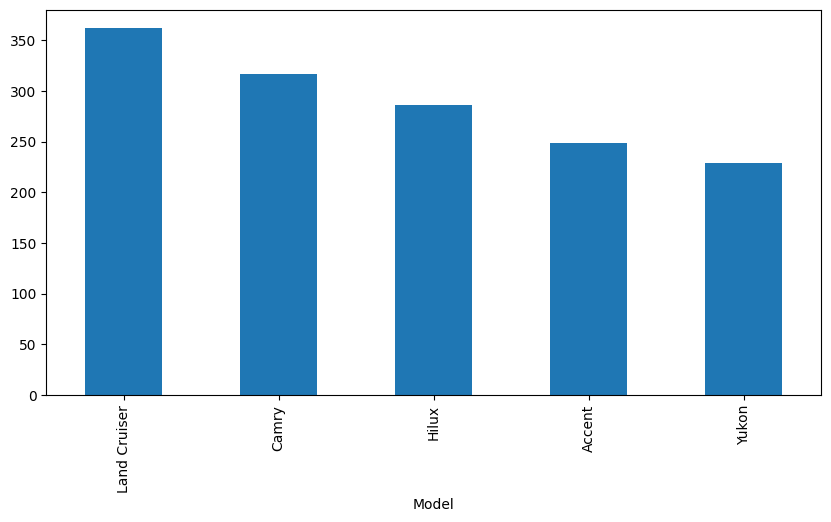

In [268]:
plt.figure(figsize=(10,5))
Top5_Models.plot(kind='bar')
plt.show()

As shown in the graph , the Land Cruiser is the most popular car in used cars market followed by Camry and Hilux , as we can see the top 3 cars are  Toyota brand which might indicate that it's the top brand in the used cars market

**What are the top 5 companies in the used cars market?**

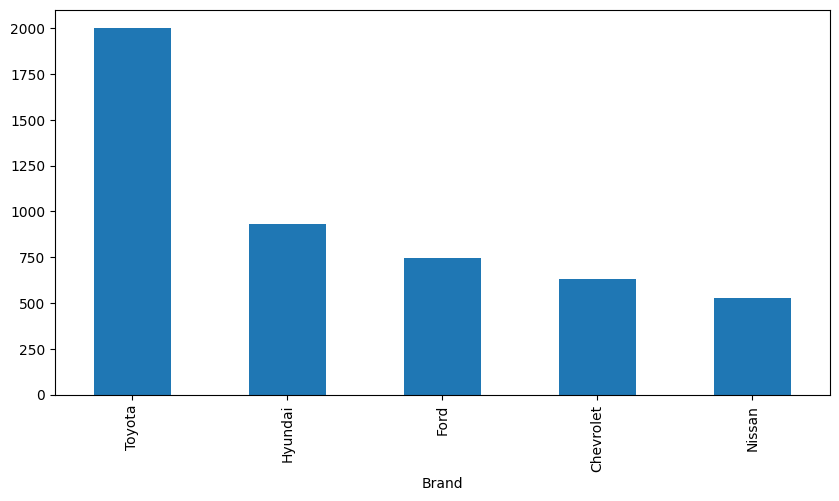

In [269]:
Top5_Brand = df['Brand'].value_counts().head(5)

plt.figure(figsize=(10,5))
Top5_Brand.plot(kind='bar')
plt.xticks(rotation=90)
plt.show()

As we figured in the figure before it's true that the top one company is Toyota with a high difference from the second one which might mean that the Saudis love Toyota (Don't we all know?)

**What are the percentage the origins represent ?**

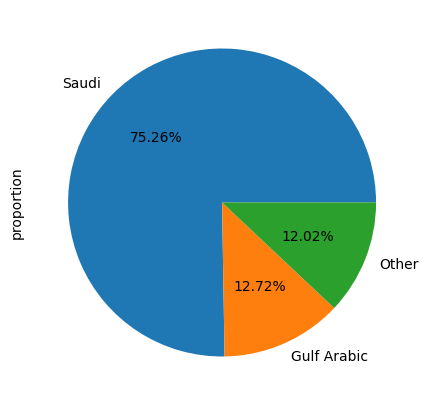

In [270]:
p_origin = df['Origin'].value_counts(normalize=True) *100

plt.figure(figsize=(10,5))
p_origin.plot(kind='pie', autopct='%1.2f%%')
plt.show()

As we can see, the top one origin is Saudi and The one next to it is Gulf Arabic with a near percentage to other which represent all other origins

**What is the popular car color ?**

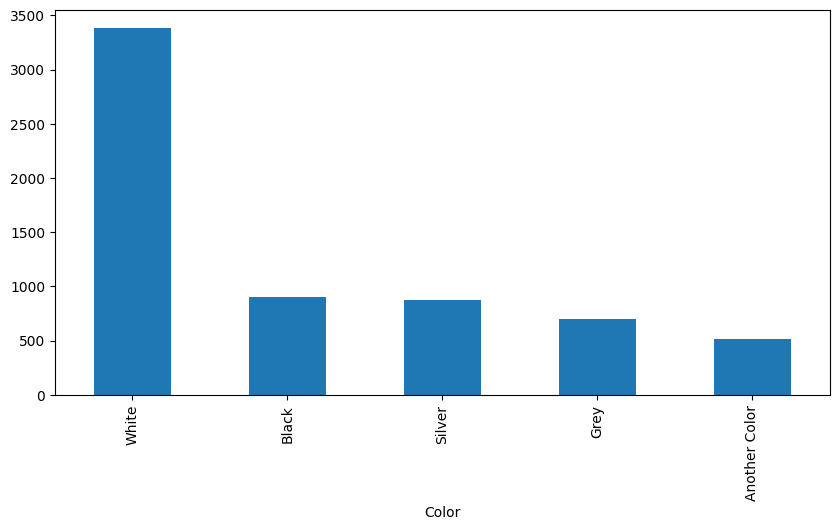

In [271]:
popular_colors = df['Color'].value_counts().head(5)

plt.figure(figsize=(10,5))
popular_colors.plot(kind='bar')
plt.show()

We can see that the most popular color is white with a very high difference from the two next to it which are black and silver , i see it as a logical choice in a hot country

**What is the popular engines size & trim choice?**

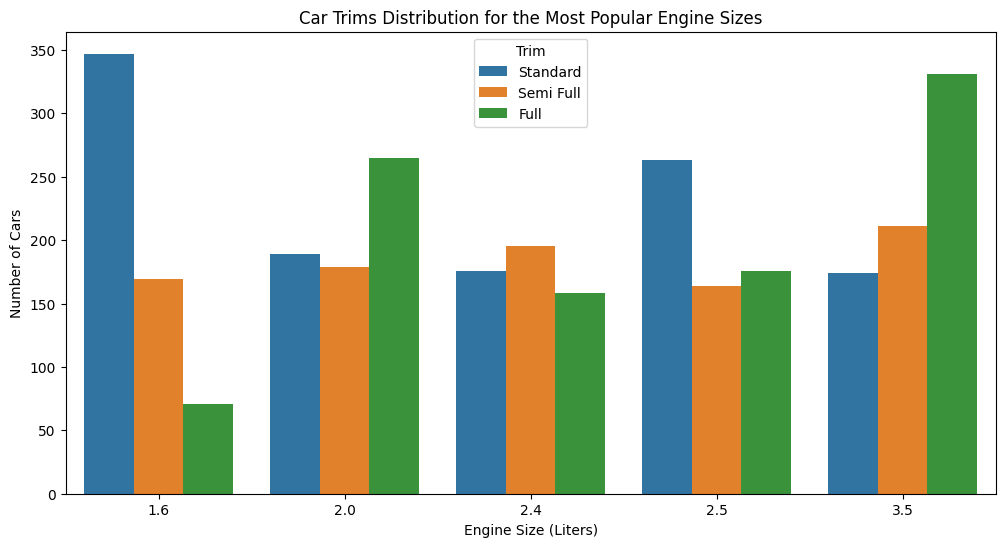

In [272]:
top_engines = df['Engine_Size'].value_counts().head(5).index

e_df = df[df['Engine_Size'].isin(top_engines)]

plt.figure(figsize=(12, 6))
sns.countplot(x='Engine_Size', hue='Trim', data=e_df, order=sorted(top_engines))

plt.title('Car Trims Distribution for the Most Popular Engine Sizes')
plt.xlabel('Engine Size (Liters)')
plt.ylabel('Number of Cars')
plt.show()

As we can see in the figure , they prefer to take Standard on the 1.6 and 2.5 engines and Semi-Full for the 2.4 but Full for the 2.0 and 3.5 engines , logically the more the engine size the higher the trim but for the 2.5 it's strange that they took standard

##feature selection

In [273]:
df

,Brand,Model,Year,Origin,Color,Trim,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,62990,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,71474,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


**What are the feature that effects the car prices?**

<Axes: >

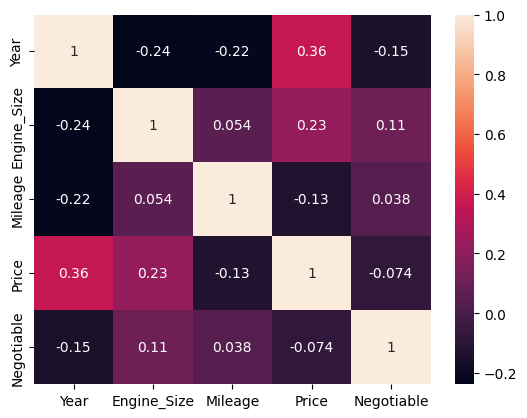

In [274]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Our target is the price and we will explore the features that effects the price

<Axes: xlabel='Year', ylabel='Price'>

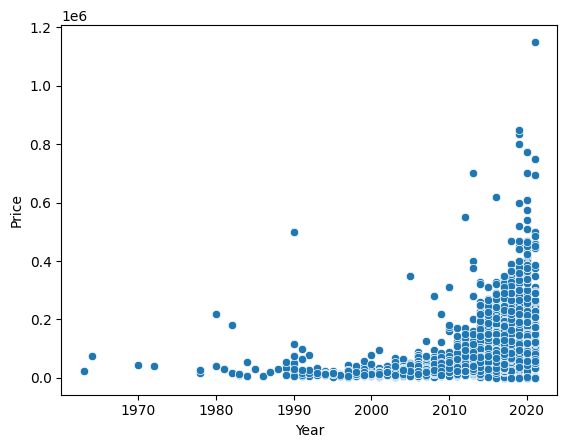

In [275]:
sns.scatterplot(x='Year' , y='Price' , data=df)

We can see that after 2010 the prices got higher as the year increased , but most cars are below 400,000 riyals and some outliers is there in 1990 and 1980 also in 2020 there are some outliers above 400,000 but the outliers are logical for luxury cars and rare classics

<Axes: xlabel='Engine_Size', ylabel='Price'>

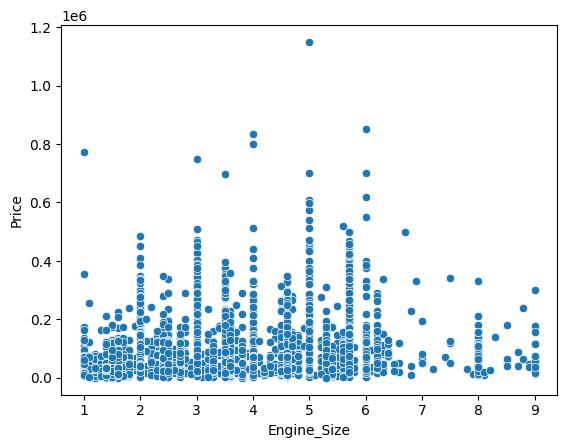

In [276]:
sns.scatterplot(x='Engine_Size' , y='Price' , data=df)

As shown in the figure , we can see that engines are below 6 and most prices are below 400,000 riyals but the outliers here are also logical as we said before they might be for luxury or rare classics and we can't remove them

<Axes: xlabel='Mileage', ylabel='Price'>

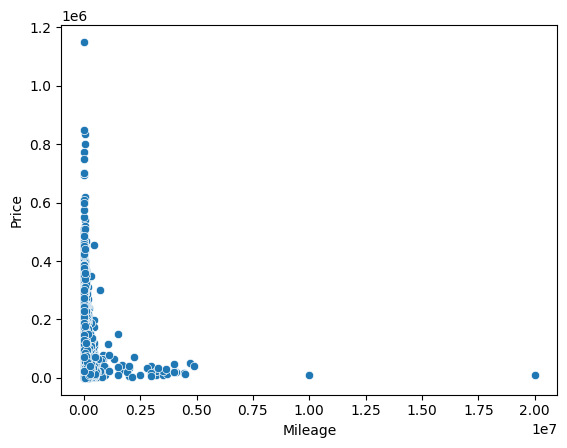

In [277]:
sns.scatterplot(x='Mileage' , y='Price' , data=df)

We can see that there are a very strange outliers i assume that they are typing mistake errors that could harm the accuracy of our  model (the 20 and 10 million) also we can notice that there is new cars and all the cars are below 500,000km but most of them are below 250,000km

<Axes: xlabel='Negotiable', ylabel='Price'>

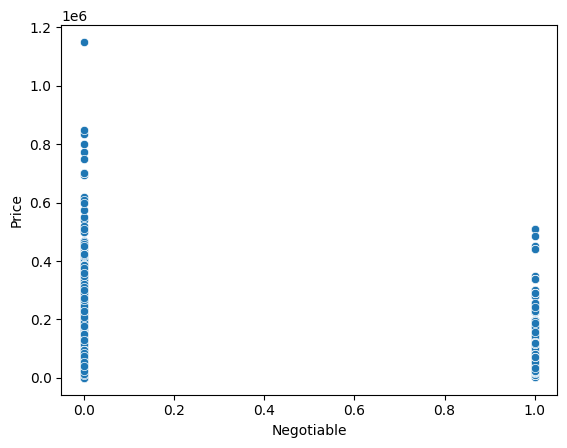

In [278]:
sns.scatterplot(x='Negotiable' , y='Price' , data=df)

As shown in the figure we can see that most negotiable and not are below 600,000 riyals which indicate that there is no relation ship between price and ngotiability

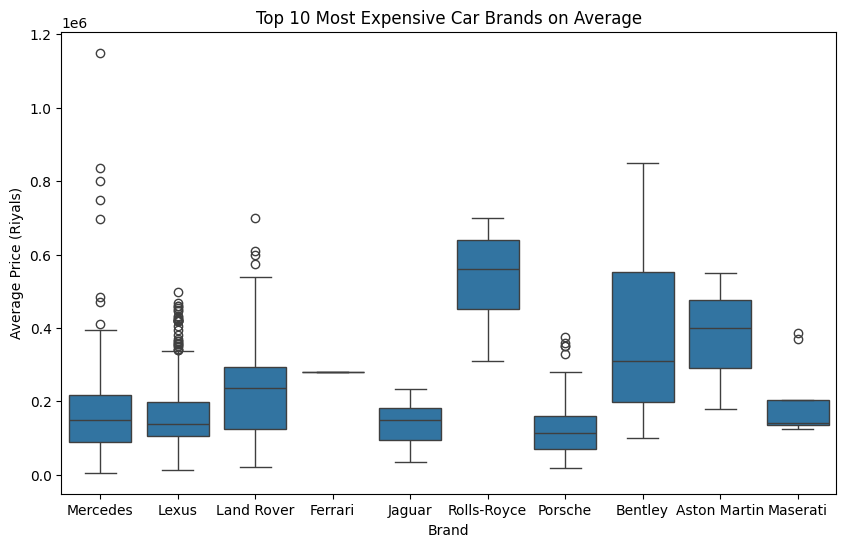

In [279]:
plt.figure(figsize=(10, 6))
B_Price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10).index
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(B_Price)])
plt.title('Top 10 Most Expensive Car Brands on Average')
plt.ylabel('Average Price (Riyals)')

plt.show()

As we can see , we see that the outliers in the plots before are from these luxury brands but some of them have cars with suitable prices in our data , like : Mercedes , Lexus and Jaguar but the median of some brands is above 400,000 riyals , like: Rolls-Royce and Aston Martin.
This indicates that the brand is highly related to the price

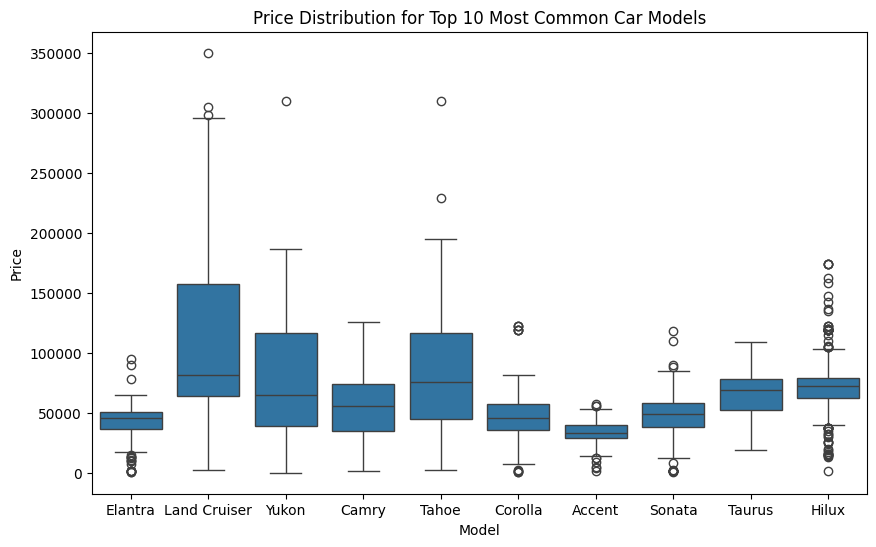

In [280]:
plt.figure(figsize=(10, 6))

top_models = df['Model'].value_counts().head(10).index
df_top_models = df[df['Model'].isin(top_models)]

sns.boxplot(x='Model', y='Price', data=df_top_models)
plt.title('Price Distribution for Top 10 Most Common Car Models')

plt.show()

The prices vary between the cars models that's why it's an important feature for predicting the price

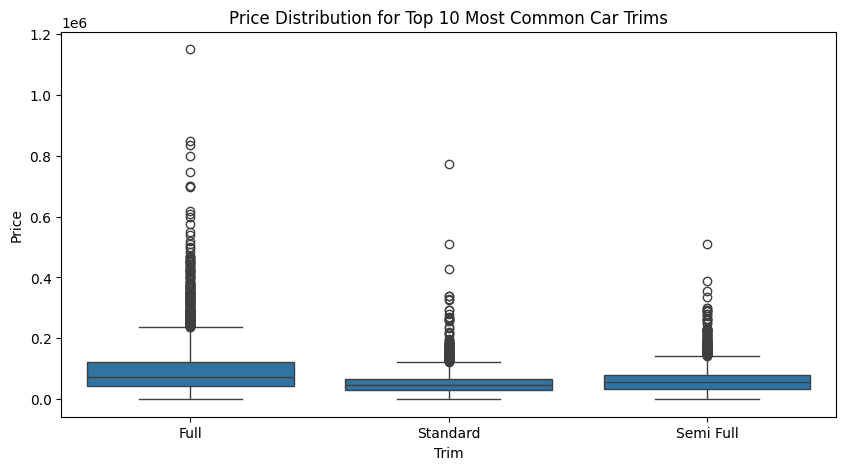

In [281]:
plt.figure(figsize=(10, 5))

top_trims = df['Trim'].value_counts().head(10).index
df_top_trims = df[df['Trim'].isin(top_trims)]

sns.boxplot(x='Trim', y='Price', data=df_top_trims)
plt.title('Price Distribution for Top 10 Most Common Car Trims')

plt.show()

as shown in the figure , we can see that the boxes are near to each other but there are alot of outliers and they are distriputed across the price , it's logical because one trim can hold classic , normal , luxury cars

<Axes: xlabel='Gear_Type', ylabel='Price'>

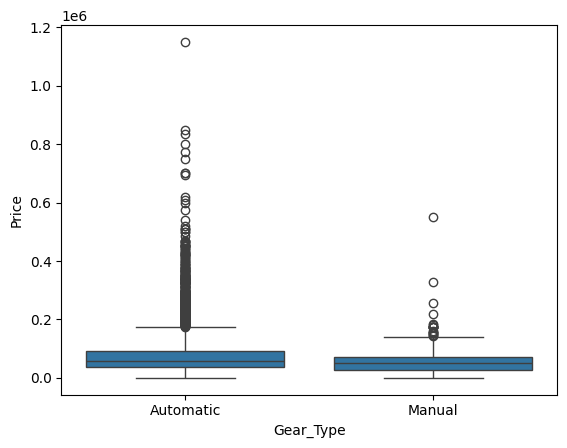

In [282]:
sns.boxplot(x='Gear_Type', y='Price', data=df)

For the manual all data are below 400,000riyals except one outlier but for the auto the data is distriputed

<Axes: xlabel='Fuel_Type', ylabel='Price'>

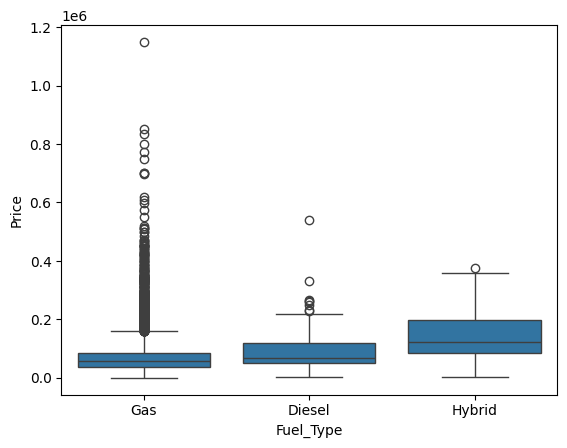

In [283]:
sns.boxplot(x='Fuel_Type', y='Price', data=df)

For Diesel and hybrid all data are below 400,000 riyals except one outlier in both

##Insights Summary

- The top Brand is Toyota and the most common color is white

- 75% of the cars are Saudi origin

- Based on the visualization, the strongest relationship with the price is the car model

- The weakest relationship with the price is the negotiability

- There are alot of outliers but they are all logical except two in the milage which are 10 and 20 million which is strange

# **Preprocces**

In [284]:
df

,Brand,Model,Year,Origin,Color,Trim,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,62990,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,Audi,A6,2015,Saudi,Silver,Full,3.0,Gas,Automatic,77000,Riyadh,75000,False
8031,Chevrolet,Camaro,2010,Saudi,Silver,Full,3.6,Gas,Automatic,150000,Riyadh,53000,False
8032,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,4.6,Gas,Automatic,260,Najran,71474,True
8033,Nissan,Altima,2011,Saudi,Silver,Full,2.5,Gas,Automatic,18500,Aseer,22000,False


In [285]:
df = df[df['Mileage'] < 9000000]

In [286]:
df[df['Mileage'] < 1000].value_counts().sum()

np.int64(888)

In [287]:
df['Is_New']= df['Mileage'].apply(lambda x: 1 if x < 1000 else 0)

/tmp/ipykernel_1855/2249902776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Is_New']= df['Mileage'].apply(lambda x: 1 if x < 1000 else 0)


In [288]:
df.to_csv('saudi_cars_cleaned_for_powerbi.csv', index=False)

In [289]:
#one-hot encoding
C_cols = ['Brand', 'Model', 'Trim','Fuel_Type','Gear_Type']

df = pd.get_dummies(df, columns=C_cols, drop_first=True, dtype=int)

In [290]:
df.head()

,Year,Origin,Color,Engine_Size,Mileage,Region,Price,Negotiable,Is_New,Brand_Audi,...,Model_Z350,Model_Z370,Model_ZS,Model_i40,Model_ِACTIS V80,Trim_Semi Full,Trim_Standard,Fuel_Type_Gas,Fuel_Type_Hybrid,Gear_Type_Manual
0,2018,Saudi,Black,5.7,103000,Riyadh,114000,False,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2016,Saudi,White,4.8,5448,Riyadh,62990,True,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2019,Saudi,Silver,1.5,72418,Riyadh,27500,False,0,0,...,0,0,0,0,0,0,1,1,0,0
3,2019,Saudi,Grey,1.6,114154,Riyadh,43000,False,0,0,...,0,0,0,0,0,0,1,1,0,0
4,2019,Saudi,Silver,2.0,41912,Riyadh,59500,False,0,0,...,0,0,0,0,0,1,0,1,0,0


In [291]:
df.to_csv('saudi_cars_cleaned.csv', index=False)

In [292]:
#target
y=df['Price']

In [293]:
#values
X = df.drop(columns=['Price','Origin','Color','Region','Negotiable'])

In [294]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [295]:
#model 1
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [296]:
#model 2
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [297]:
y_pred_lr_train = linear_model.predict(X_train)
y_pred_lr_test = linear_model.predict(X_test)


lr_r2_train = r2_score(y_train, y_pred_lr_train)
lr_r2_test = r2_score(y_test, y_pred_lr_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr_test)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

rf_r2_train = r2_score(y_train, y_pred_rf_train)
rf_r2_test = r2_score(y_test, y_pred_rf_test)
rf_mae = mean_absolute_error(y_test, y_pred_rf_test)


print(f"Train R2 Score \nlinear: {lr_r2_train:.2%} \nrandom forest: {rf_r2_train:.2%}")
print(f"\nTest R2 Score \nlinear: {lr_r2_test:.2%} \nrandom forest: {rf_r2_test:.2%}")
print(f"\nMAE (Mean Absolute Error) \nlinear: {lr_mae:,.2f} SR \nrandom forest: {rf_mae:,.2f} SR")

Train R2 Score 
linear: 69.05% 
random forest: 96.49%

Test R2 Score 
linear: 60.88% 
random forest: 80.75%

MAE (Mean Absolute Error) 
linear: 23,759.37 SR 
random forest: 15,984.75 SR


In [298]:
import joblib
joblib.dump(rf_model, 'car_price_model.pkl')

['car_price_model.pkl']